In [1]:
# STEP 1 — Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import os

BASE_PATH = "/content/drive/MyDrive/NewsGuard"
PROCESSED_PATH = os.path.join(BASE_PATH, "processed")

train_data = pd.read_csv(
    os.path.join(PROCESSED_PATH, "train_preprocessed.csv")
)

valid_data = pd.read_csv(
    os.path.join(PROCESSED_PATH, "validation_preprocessed.csv")
)

test_data = pd.read_csv(
    os.path.join(PROCESSED_PATH, "test_preprocessed.csv")
)

full_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "liar_preprocessed.csv")
)

print("Train:", train_data.shape)
print("Validation:", valid_data.shape)
print("Test:", test_data.shape)
print("Full:", full_df.shape)

Train: (10212, 17)
Validation: (1276, 17)
Test: (1277, 17)
Full: (12765, 15)


In [3]:
print("FULL COLUMNS:")
print(full_df.columns.tolist())

print("\nTRAIN COLUMNS:")
print(train_data.columns.tolist())

print("\nEXTRA TRAIN COLUMNS:")
print([col for col in train_data.columns if col not in full_df.columns])

FULL COLUMNS:
['label', 'statement', 'subject', 'speaker', 'speaker_job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'binary_label', 'cleaned_statement']

TRAIN COLUMNS:
['label', 'statement', 'subject', 'speaker', 'speaker_job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'binary_label', 'cleaned_statement', 'original_words', 'cleaned_words']

EXTRA TRAIN COLUMNS:
['original_words', 'cleaned_words']


In [4]:
print("\nFirst 5 rows of train:")
display(train_data.head())


First 5 rows of train:


,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,binary_label,cleaned_statement,original_words,cleaned_words
0,half-true,There is no precedent for what the Democrats a...,health-care,cliff-stearns,U.S. representative,Florida,republican,0.0,0.0,2.0,1.0,0.0,a speech on the House floor,Fake,precedent democrats deception never write reco...,29,10
1,mostly-true,"14,000 Americans . . . lose their health insur...",health-care,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,a news conference.,Real,14000 americans lose health insurance every si...,12,8
2,mostly-true,"The Democrats' health care bills would end ""th...","health-care,abc-news-week",nancy-pelosi,House Minority Leader,California,democrat,3.0,7.0,11.0,2.0,3.0,an interview on ABC's 'This Week',Real,democrats health care bill would end denial co...,25,13
3,false,Says eight Americans died in a knife attack at...,"guns,terrorism",tom-tancredo,U.S. representative,Colorado,republican,2.0,4.0,1.0,1.0,0.0,a fundraising email,Fake,say eight americans die knife attack minnesota...,12,8
4,mostly-true,TheU.S. economyis three times asbig as Chinas.,"china,economy",eric-cantor,House Majority Leader,Virginia,republican,9.0,6.0,4.0,4.0,4.0,a news conference.,Real,theus economyis three time asbig china,7,6


In [5]:
# Day 3 — Step 2.1
# TF-IDF imports

from sklearn.feature_extraction.text import TfidfVectorizer

print("TF-IDF imported successfully!")

TF-IDF imported successfully!


In [6]:
# Day 3 — Step 2.2
# Create TF-IDF Vectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

print("TF-IDF Vectorizer created successfully!")

TF-IDF Vectorizer created successfully!


In [7]:
# Fit TF-IDF on training data and transform all splits

X_train_tfidf = tfidf.fit_transform(train_data["cleaned_statement"])
X_valid_tfidf = tfidf.transform(valid_data["cleaned_statement"])
X_test_tfidf = tfidf.transform(test_data["cleaned_statement"])

print("TF-IDF transformation completed!")
print("Train:", X_train_tfidf.shape)
print("Validation:", X_valid_tfidf.shape)
print("Test:", X_test_tfidf.shape)

TF-IDF transformation completed!
Train: (10212, 5000)
Validation: (1276, 5000)
Test: (1277, 5000)


In [8]:
# Inspect TF-IDF feature names and sample values

feature_names = tfidf.get_feature_names_out()

print("Total TF-IDF features:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

print("\nTF-IDF matrix type:", type(X_train_tfidf))
print("Sample non-zero values in first training statement:")
print(X_train_tfidf[0].toarray()[0][X_train_tfidf[0].toarray()[0] > 0][:20])

Total TF-IDF features: 5000

First 20 features:
['10' '10 billion' '10 day' '10 million' '10 percent' '10 time' '10 year'
 '100' '100 billion' '100 day' '100 million' '100 percent' '1000' '10000'
 '100000' '100000 job' '100000 people' '1010' '103' '105']

TF-IDF matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Sample non-zero values in first training statement:
[0.46886766 0.23166335 0.29885341 0.38958378 0.24018409 0.28211674
 0.46886766 0.35817761]


In [9]:
# Day 3 — Step 2.5
# Check TF-IDF sparsity and density

total_values = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
non_zero_values = X_train_tfidf.nnz
zero_values = total_values - non_zero_values
density = (non_zero_values / total_values) * 100

print("Total values:", total_values)
print("Non-zero values:", non_zero_values)
print("Zero values:", zero_values)
print(f"Matrix density: {density:.4f}%")
print(f"Matrix sparsity: {100 - density:.4f}%")

Total values: 51060000
Non-zero values: 119739
Zero values: 50940261
Matrix density: 0.2345%
Matrix sparsity: 99.7655%


In [10]:
# Day 3 — Step 2.6
# Save TF-IDF vectorizer and feature matrices

import os
import joblib
from scipy.sparse import save_npz

FEATURE_PATH = os.path.join(BASE_PATH, "features")
os.makedirs(FEATURE_PATH, exist_ok=True)

joblib.dump(
    tfidf,
    os.path.join(FEATURE_PATH, "tfidf_vectorizer.pkl")
)

save_npz(
    os.path.join(FEATURE_PATH, "X_train_tfidf.npz"),
    X_train_tfidf
)

save_npz(
    os.path.join(FEATURE_PATH, "X_valid_tfidf.npz"),
    X_valid_tfidf
)

save_npz(
    os.path.join(FEATURE_PATH, "X_test_tfidf.npz"),
    X_test_tfidf
)

print("TF-IDF vectorizer and matrices saved successfully!")
print("Saved to:", FEATURE_PATH)

TF-IDF vectorizer and matrices saved successfully!
Saved to: /content/drive/MyDrive/NewsGuard/features


In [11]:
# Day 3 — Step 2.7
# Verify saved TF-IDF files

import os

saved_files = os.listdir(FEATURE_PATH)

print("Files in features directory:")
for file in sorted(saved_files):
    print("→", file)

Files in features directory:
→ X_test_tfidf.npz
→ X_train_tfidf.npz
→ X_valid_tfidf.npz
→ tfidf_vectorizer.pkl


In [12]:
# Day 3 — Step 2.8
# Check TF-IDF feature statistics

import numpy as np

feature_values = X_train_tfidf.data

print("TF-IDF Feature Statistics")
print("-" * 35)
print(f"Minimum value: {feature_values.min():.6f}")
print(f"Maximum value: {feature_values.max():.6f}")
print(f"Mean value:    {feature_values.mean():.6f}")
print(f"Median value:  {np.median(feature_values):.6f}")
print(f"Non-zero values: {len(feature_values)}")

TF-IDF Feature Statistics
-----------------------------------
Minimum value: 0.017578
Maximum value: 1.000000
Mean value:    0.274953
Median value:  0.263809
Non-zero values: 119739


In [13]:
# Day 3 — Step 2.9
# Analyze top TF-IDF features

import numpy as np

mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()

top_indices = mean_tfidf.argsort()[-20:][::-1]

top_features = feature_names[top_indices]
top_scores = mean_tfidf[top_indices]

print("Top 20 TF-IDF features:")
for feature, score in zip(top_features, top_scores):
    print(f"{feature:<30} {score:.6f}")

Top 20 TF-IDF features:
say                            0.030728
percent                        0.016622
year                           0.016183
state                          0.015409
obama                          0.012705
job                            0.010946
tax                            0.010844
president                      0.010769
health                         0.010216
vote                           0.010192
people                         0.010045
not                            0.010010
million                        0.009930
would                          0.009110
care                           0.008998
go                             0.008897
one                            0.008707
bill                           0.008182
pay                            0.008176
new                            0.008168


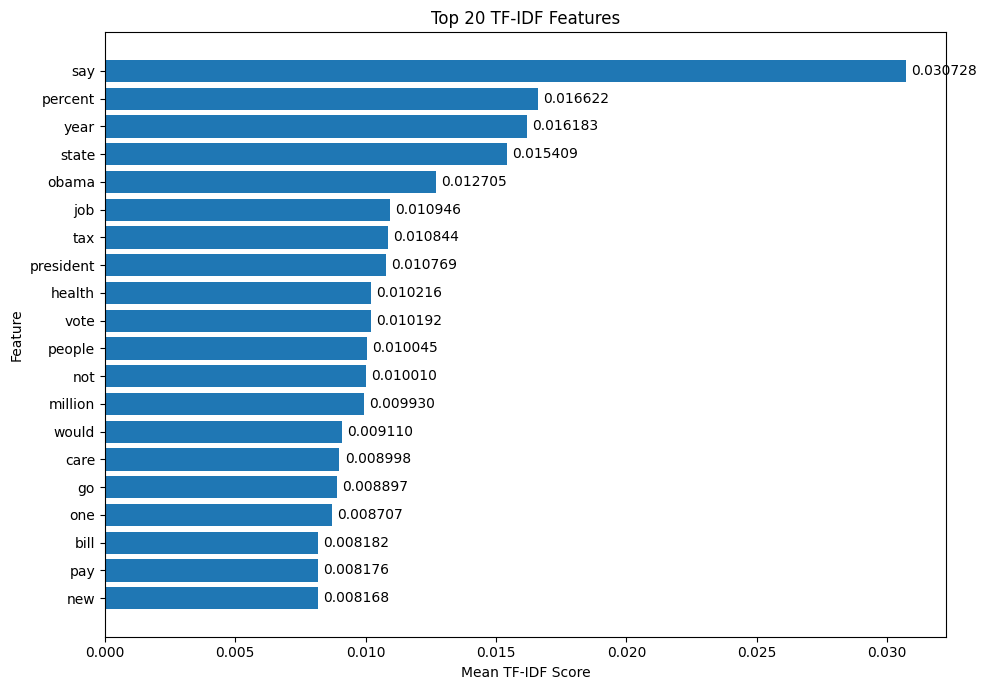

Figure saved successfully!
Saved to: /content/drive/MyDrive/NewsGuard/results/figures/top_20_tfidf_features.png


In [15]:
# Day 3 — Step 2.10
# Plot top 20 TF-IDF features with values

import matplotlib.pyplot as plt
import os

FIGURE_PATH = os.path.join(BASE_PATH, "results", "figures")
os.makedirs(FIGURE_PATH, exist_ok=True)

plt.figure(figsize=(10, 7))

bars = plt.barh(top_features[::-1], top_scores[::-1])

plt.xlabel("Mean TF-IDF Score")
plt.ylabel("Feature")
plt.title("Top 20 TF-IDF Features")

# Add values at the end of each bar
for bar, score in zip(bars, top_scores[::-1]):
    plt.text(
        bar.get_width() + 0.0002,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.6f}",
        va="center"
    )

plt.tight_layout()

figure_file = os.path.join(
    FIGURE_PATH,
    "top_20_tfidf_features.png"
)

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully!")
print("Saved to:", figure_file)

In [16]:
# Day 3 — Step 3.1
# Word2Vec setup

!pip install -q gensim

from gensim.models import Word2Vec

print("Word2Vec imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 42.8 MB/s eta 0:00:00
Word2Vec imported successfully!


In [17]:
# Day 3 — Step 3.2
# Prepare tokenized text for Word2Vec

train_sentences = train_data["cleaned_statement"].apply(str.split).tolist()
valid_sentences = valid_data["cleaned_statement"].apply(str.split).tolist()
test_sentences = test_data["cleaned_statement"].apply(str.split).tolist()

print("Tokenized text prepared successfully!")
print("Train sentences:", len(train_sentences))
print("Validation sentences:", len(valid_sentences))
print("Test sentences:", len(test_sentences))

Tokenized text prepared successfully!
Train sentences: 10212
Validation sentences: 1276
Test sentences: 1277


In [18]:
# Day 3 — Step 3.3
# Train Word2Vec model on training text

word2vec_model = Word2Vec(
    sentences=train_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    seed=42
)

print("Word2Vec model trained successfully!")
print("Vocabulary size:", len(word2vec_model.wv))
print("Embedding size:", word2vec_model.vector_size)

Word2Vec model trained successfully!
Vocabulary size: 5581
Embedding size: 100


In [19]:
# Day 3 — Step 3.4
# Create sentence embeddings using Word2Vec

import numpy as np

def get_sentence_vector(tokens, model):
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X_train_w2v = np.array([
    get_sentence_vector(tokens, word2vec_model)
    for tokens in train_sentences
])

X_valid_w2v = np.array([
    get_sentence_vector(tokens, word2vec_model)
    for tokens in valid_sentences
])

X_test_w2v = np.array([
    get_sentence_vector(tokens, word2vec_model)
    for tokens in test_sentences
])

print("Word2Vec sentence embeddings created successfully!")
print("Train:", X_train_w2v.shape)
print("Validation:", X_valid_w2v.shape)
print("Test:", X_test_w2v.shape)

Word2Vec sentence embeddings created successfully!
Train: (10212, 100)
Validation: (1276, 100)
Test: (1277, 100)


In [20]:
# Day 3 — Step 3.5
# Inspect Word2Vec embeddings

print("Vocabulary size:", len(word2vec_model.wv))
print("Embedding dimension:", word2vec_model.vector_size)

sample_word = "president"

if sample_word in word2vec_model.wv:
    print(f"\nVector for '{sample_word}':")
    print(word2vec_model.wv[sample_word])
    print("\nVector shape:", word2vec_model.wv[sample_word].shape)
else:
    print(f"'{sample_word}' is not present in the vocabulary.")

Vocabulary size: 5581
Embedding dimension: 100

Vector for 'president':
[ 5.56798756e-01  4.32654232e-01  5.10242209e-02 -4.19686645e-01
 -4.45202649e-01  2.87923932e-01  3.58996660e-01  2.99490958e-01
 -1.04708686e-01 -4.47400421e-01 -3.99265617e-01 -5.71808256e-02
 -1.18823752e-01  6.77742243e-01  5.90157062e-02 -8.25209692e-02
  1.19285144e-01 -3.96639019e-01 -1.23899490e-01  4.88289341e-04
  5.10476381e-02  4.66662645e-01  3.40452105e-01  3.93446565e-01
  4.93935198e-01 -1.95942774e-01  5.62951714e-02  2.11682364e-01
 -2.61102051e-01  7.28385597e-02 -1.66475736e-02 -3.31130058e-01
  4.87448931e-01 -3.93370181e-01  6.39250949e-02  1.66940436e-01
  4.22477834e-02 -2.56875575e-01  3.18740696e-01  3.59074742e-01
  2.90298969e-01  2.44467527e-01  6.73067689e-01 -1.89551845e-01
  2.48899475e-01  6.17020316e-02  1.60188735e-01  9.10598785e-02
  2.20118731e-01 -2.44932503e-01 -1.55524462e-01 -2.29262486e-01
 -3.48956645e-01 -3.35616395e-02  1.41788930e-01 -3.05033296e-01
 -1.99848056e-01 -

In [21]:
# Day 3 — Step 3.6
# Save Word2Vec model and sentence embeddings

import os
import joblib
import numpy as np

features_dir = "/content/drive/MyDrive/NewsGuard/features"
os.makedirs(features_dir, exist_ok=True)

word2vec_model.save(
    os.path.join(features_dir, "word2vec_model.model")
)

np.save(
    os.path.join(features_dir, "X_train_w2v.npy"),
    X_train_w2v
)

np.save(
    os.path.join(features_dir, "X_valid_w2v.npy"),
    X_valid_w2v
)

np.save(
    os.path.join(features_dir, "X_test_w2v.npy"),
    X_test_w2v
)

print("Word2Vec model and embeddings saved successfully!")
print("Saved to:", features_dir)

Word2Vec model and embeddings saved successfully!
Saved to: /content/drive/MyDrive/NewsGuard/features


In [22]:
# Day 3 — Step 3.7
# Verify Word2Vec files

import os

expected_files = [
    "word2vec_model.model",
    "X_train_w2v.npy",
    "X_valid_w2v.npy",
    "X_test_w2v.npy"
]

print("Checking saved Word2Vec files...\n")

for file_name in expected_files:
    file_path = os.path.join(features_dir, file_name)

    if os.path.exists(file_path):
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"✓ {file_name} — {size_mb:.2f} MB")
    else:
        print(f"✗ {file_name} — NOT FOUND")

Checking saved Word2Vec files...

✓ word2vec_model.model — 4.42 MB
✓ X_train_w2v.npy — 3.90 MB
✓ X_valid_w2v.npy — 0.49 MB
✓ X_test_w2v.npy — 0.49 MB


In [23]:
# Day 3 — Step 3.8
# Check Word2Vec embedding statistics

print("Word2Vec Embedding Statistics")
print("-" * 40)

print("Train shape:", X_train_w2v.shape)
print("Validation shape:", X_valid_w2v.shape)
print("Test shape:", X_test_w2v.shape)

print("\nTrain mean:", X_train_w2v.mean())
print("Train std:", X_train_w2v.std())
print("Train min:", X_train_w2v.min())
print("Train max:", X_train_w2v.max())

zero_rows = np.all(X_train_w2v == 0, axis=1)

print("\nZero-vector training samples:", zero_rows.sum())
print("Non-zero training samples:", (~zero_rows).sum())

Word2Vec Embedding Statistics
----------------------------------------
Train shape: (10212, 100)
Validation shape: (1276, 100)
Test shape: (1277, 100)

Train mean: -0.0071246694
Train std: 0.16960613
Train min: -1.057553
Train max: 0.79037064

Zero-vector training samples: 0
Non-zero training samples: 10212


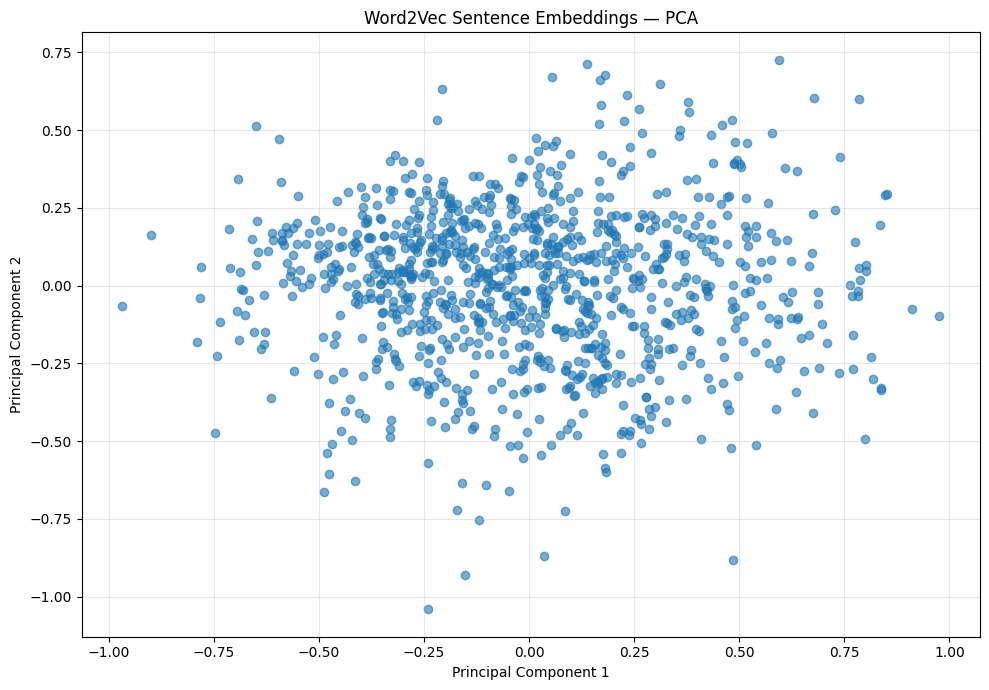

PCA visualization saved successfully!
Saved to: /content/drive/MyDrive/NewsGuard/results/figures/word2vec_pca.png
Explained variance: [0.26690733 0.14375639]


In [24]:
# Day 3 — Step 3.9
# Visualize Word2Vec embeddings using PCA

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Use a sample for visualization
sample_size = min(1000, len(X_train_w2v))

X_sample = X_train_w2v[:sample_size]

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(10, 7))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.6
)

plt.title("Word2Vec Sentence Embeddings — PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, alpha=0.3)

plt.tight_layout()

pca_path = "/content/drive/MyDrive/NewsGuard/results/figures/word2vec_pca.png"
plt.savefig(pca_path, dpi=300, bbox_inches="tight")
plt.show()

print("PCA visualization saved successfully!")
print("Saved to:", pca_path)
print("Explained variance:", pca.explained_variance_ratio_)

In [25]:
# Day 3 — Step 3.10
# Final Word2Vec verification

print("Word2Vec feature extraction completed successfully!")
print("-" * 50)

print("Vocabulary size       :", len(word2vec_model.wv))
print("Embedding dimension   :", word2vec_model.vector_size)

print("\nFeature shapes:")
print("Train                 :", X_train_w2v.shape)
print("Validation            :", X_valid_w2v.shape)
print("Test                  :", X_test_w2v.shape)

print("\nSaved artifacts:")
print("✓ word2vec_model.model")
print("✓ X_train_w2v.npy")
print("✓ X_valid_w2v.npy")
print("✓ X_test_w2v.npy")
print("✓ word2vec_pca.png")

print("\nDay 3 — Word2Vec completed successfully! ✅")

Word2Vec feature extraction completed successfully!
--------------------------------------------------
Vocabulary size       : 5581
Embedding dimension   : 100

Feature shapes:
Train                 : (10212, 100)
Validation            : (1276, 100)
Test                  : (1277, 100)

Saved artifacts:
✓ word2vec_model.model
✓ X_train_w2v.npy
✓ X_valid_w2v.npy
✓ X_test_w2v.npy
✓ word2vec_pca.png

Day 3 — Word2Vec completed successfully! ✅


In [26]:
# Day 3 — Step 4.1
# Readability score setup

!pip install -q textstat

import textstat

print("textstat imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.7 MB/s eta 0:00:00
textstat imported successfully!


In [27]:
# Day 3 — Step 4.2
# Calculate readability scores for all statements

def get_readability_features(text):
    if not isinstance(text, str) or not text.strip():
        return [0.0, 0.0, 0.0, 0.0]

    return [
        textstat.flesch_reading_ease(text),
        textstat.flesch_kincaid_grade(text),
        textstat.automated_readability_index(text),
        textstat.smog_index(text)
    ]

readability_columns = [
    "flesch_reading_ease",
    "flesch_kincaid_grade",
    "automated_readability_index",
    "smog_index"
]

train_readability = np.array([
    get_readability_features(text)
    for text in train_data["statement"]
])

valid_readability = np.array([
    get_readability_features(text)
    for text in valid_data["statement"]
])

test_readability = np.array([
    get_readability_features(text)
    for text in test_data["statement"]
])

print("Readability features calculated successfully!")
print("Train:", train_readability.shape)
print("Validation:", valid_readability.shape)
print("Test:", test_readability.shape)
print("\nFeatures:", readability_columns)

Readability features calculated successfully!
Train: (10212, 4)
Validation: (1276, 4)
Test: (1277, 4)

Features: ['flesch_reading_ease', 'flesch_kincaid_grade', 'automated_readability_index', 'smog_index']


In [28]:
# Day 3 — Step 4.3
# Inspect readability feature statistics

print("Readability Feature Statistics")
print("-" * 50)

for i, feature in enumerate(readability_columns):
    values = train_readability[:, i]

    print(f"\n{feature}")
    print(f"Mean   : {values.mean():.4f}")
    print(f"Std    : {values.std():.4f}")
    print(f"Min    : {values.min():.4f}")
    print(f"Max    : {values.max():.4f}")
    print(f"Median : {np.median(values):.4f}")

Readability Feature Statistics
--------------------------------------------------

flesch_reading_ease
Mean   : 54.1833
Std    : 21.2215
Min    : -91.2950
Max    : 119.1900
Median : 55.4231

flesch_kincaid_grade
Mean   : 9.5766
Std    : 3.7179
Min    : -2.6200
Max    : 27.2740
Median : 9.4492

automated_readability_index
Mean   : 10.2092
Std    : 4.3599
Min    : -6.4775
Max    : 35.7864
Median : 10.0649

smog_index
Mean   : 11.4039
Std    : 3.6025
Min    : 3.1291
Max    : 25.2545
Median : 11.2081


In [29]:
# Day 3 — Step 4.4
# Save readability features to Google Drive

readability_dir = "/content/drive/MyDrive/NewsGuard/features"

np.save(
    os.path.join(readability_dir, "X_train_readability.npy"),
    train_readability
)

np.save(
    os.path.join(readability_dir, "X_valid_readability.npy"),
    valid_readability
)

np.save(
    os.path.join(readability_dir, "X_test_readability.npy"),
    test_readability
)

joblib.dump(
    readability_columns,
    os.path.join(readability_dir, "readability_features.pkl")
)

print("Readability features saved successfully!")
print("Saved to:", readability_dir)

Readability features saved successfully!
Saved to: /content/drive/MyDrive/NewsGuard/features


In [30]:
# Day 3 — Step 4.5
# Verify saved readability files

expected_readability_files = [
    "X_train_readability.npy",
    "X_valid_readability.npy",
    "X_test_readability.npy",
    "readability_features.pkl"
]

print("Checking saved readability files...\n")

for file_name in expected_readability_files:
    file_path = os.path.join(readability_dir, file_name)

    if os.path.exists(file_path):
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"✓ {file_name} — {size_mb:.2f} MB")
    else:
        print(f"✗ {file_name} — NOT FOUND")

Checking saved readability files...

✓ X_train_readability.npy — 0.31 MB
✓ X_valid_readability.npy — 0.04 MB
✓ X_test_readability.npy — 0.04 MB
✓ readability_features.pkl — 0.00 MB


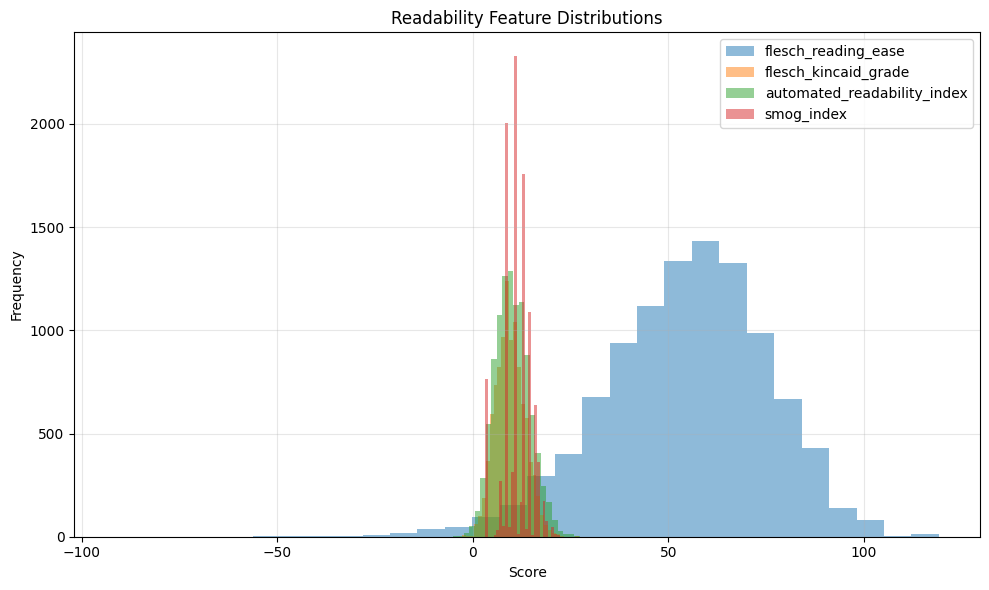

Readability visualization saved successfully!
Saved to: /content/drive/MyDrive/NewsGuard/results/figures/readability_distributions.png


In [31]:
# Day 3 — Step 4.6
# Visualize readability feature distributions

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for i, feature in enumerate(readability_columns):
    plt.hist(
        train_readability[:, i],
        bins=30,
        alpha=0.5,
        label=feature
    )

plt.title("Readability Feature Distributions")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

readability_plot_path = (
    "/content/drive/MyDrive/NewsGuard/results/figures/"
    "readability_distributions.png"
)

plt.savefig(
    readability_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Readability visualization saved successfully!")
print("Saved to:", readability_plot_path)

In [32]:
# Day 3 — Step 4.7
# Final readability verification

print("Readability feature extraction completed successfully!")
print("-" * 55)

print("Features:", readability_columns)

print("\nFeature shapes:")
print("Train      :", train_readability.shape)
print("Validation :", valid_readability.shape)
print("Test       :", test_readability.shape)

print("\nSaved artifacts:")
print("✓ X_train_readability.npy")
print("✓ X_valid_readability.npy")
print("✓ X_test_readability.npy")
print("✓ readability_features.pkl")
print("✓ readability_distributions.png")

print("\nDay 3 — Readability features completed successfully! ✅")

Readability feature extraction completed successfully!
-------------------------------------------------------
Features: ['flesch_reading_ease', 'flesch_kincaid_grade', 'automated_readability_index', 'smog_index']

Feature shapes:
Train      : (10212, 4)
Validation : (1276, 4)
Test       : (1277, 4)

Saved artifacts:
✓ X_train_readability.npy
✓ X_valid_readability.npy
✓ X_test_readability.npy
✓ readability_features.pkl
✓ readability_distributions.png

Day 3 — Readability features completed successfully! ✅


In [33]:
# Day 3 — Step 5.1
# Sentiment analysis setup

from textblob import TextBlob

print("TextBlob imported successfully!")

TextBlob imported successfully!


In [34]:
# Day 3 — Step 5.2
# Calculate sentiment polarity for all statements

def get_sentiment_polarity(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0

    return TextBlob(text).sentiment.polarity


train_sentiment = np.array([
    get_sentiment_polarity(text)
    for text in train_data["statement"]
])

valid_sentiment = np.array([
    get_sentiment_polarity(text)
    for text in valid_data["statement"]
])

test_sentiment = np.array([
    get_sentiment_polarity(text)
    for text in test_data["statement"]
])

print("Sentiment polarity calculated successfully!")
print("Train:", train_sentiment.shape)
print("Validation:", valid_sentiment.shape)
print("Test:", test_sentiment.shape)

Sentiment polarity calculated successfully!
Train: (10212,)
Validation: (1276,)
Test: (1277,)


In [35]:
# Day 3 — Step 5.3
# Inspect sentiment polarity statistics

print("Sentiment Polarity Statistics")
print("-" * 45)

print(f"Mean   : {train_sentiment.mean():.4f}")
print(f"Std    : {train_sentiment.std():.4f}")
print(f"Min    : {train_sentiment.min():.4f}")
print(f"Max    : {train_sentiment.max():.4f}")
print(f"Median : {np.median(train_sentiment):.4f}")

print("\nNeutral samples:", np.sum(train_sentiment == 0))
print("Positive samples:", np.sum(train_sentiment > 0))
print("Negative samples:", np.sum(train_sentiment < 0))

Sentiment Polarity Statistics
---------------------------------------------
Mean   : 0.0509
Std    : 0.2096
Min    : -1.0000
Max    : 1.0000
Median : 0.0000

Neutral samples: 4614
Positive samples: 3679
Negative samples: 1919


In [36]:
# Day 3 — Step 5.4
# Save sentiment features to Google Drive

sentiment_dir = "/content/drive/MyDrive/NewsGuard/features"

np.save(
    os.path.join(sentiment_dir, "X_train_sentiment.npy"),
    train_sentiment
)

np.save(
    os.path.join(sentiment_dir, "X_valid_sentiment.npy"),
    valid_sentiment
)

np.save(
    os.path.join(sentiment_dir, "X_test_sentiment.npy"),
    test_sentiment
)

joblib.dump(
    "sentiment_polarity",
    os.path.join(sentiment_dir, "sentiment_feature.pkl")
)

print("Sentiment features saved successfully!")
print("Saved to:", sentiment_dir)

Sentiment features saved successfully!
Saved to: /content/drive/MyDrive/NewsGuard/features


In [37]:
# Day 3 — Step 5.5
# Verify saved sentiment files

expected_sentiment_files = [
    "X_train_sentiment.npy",
    "X_valid_sentiment.npy",
    "X_test_sentiment.npy",
    "sentiment_feature.pkl"
]

print("Checking saved sentiment files...\n")

for file_name in expected_sentiment_files:
    file_path = os.path.join(sentiment_dir, file_name)

    if os.path.exists(file_path):
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"✓ {file_name} — {size_mb:.2f} MB")
    else:
        print(f"✗ {file_name} — NOT FOUND")

Checking saved sentiment files...

✓ X_train_sentiment.npy — 0.08 MB
✓ X_valid_sentiment.npy — 0.01 MB
✓ X_test_sentiment.npy — 0.01 MB
✓ sentiment_feature.pkl — 0.00 MB


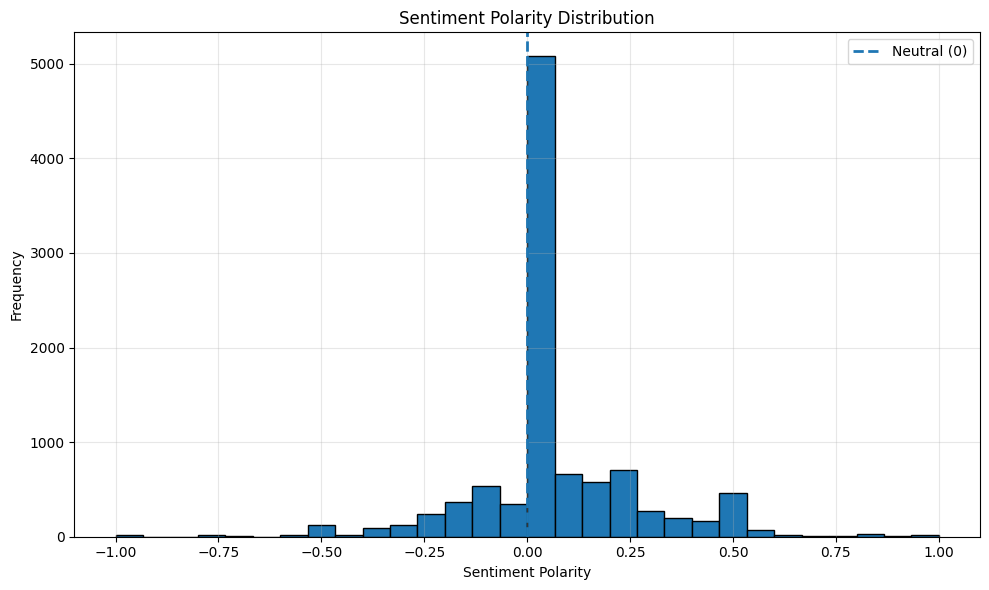

Sentiment visualization saved successfully!
Saved to: /content/drive/MyDrive/NewsGuard/results/figures/sentiment_polarity_distribution.png


In [38]:
# Day 3 — Step 5.6
# Visualize sentiment polarity distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    train_sentiment,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Neutral (0)"
)

plt.title("Sentiment Polarity Distribution")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

sentiment_plot_path = (
    "/content/drive/MyDrive/NewsGuard/results/figures/"
    "sentiment_polarity_distribution.png"
)

plt.savefig(
    sentiment_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Sentiment visualization saved successfully!")
print("Saved to:", sentiment_plot_path)

In [39]:
# Day 3 — Step 5.7
# Final sentiment verification

print("Sentiment feature extraction completed successfully!")
print("-" * 55)

print("Feature: sentiment_polarity")

print("\nFeature shapes:")
print("Train      :", train_sentiment.shape)
print("Validation :", valid_sentiment.shape)
print("Test       :", test_sentiment.shape)

print("\nSaved artifacts:")
print("✓ X_train_sentiment.npy")
print("✓ X_valid_sentiment.npy")
print("✓ X_test_sentiment.npy")
print("✓ sentiment_feature.pkl")
print("✓ sentiment_polarity_distribution.png")

print("\nDay 3 — Sentiment features completed successfully! ✅")

Sentiment feature extraction completed successfully!
-------------------------------------------------------
Feature: sentiment_polarity

Feature shapes:
Train      : (10212,)
Validation : (1276,)
Test       : (1277,)

Saved artifacts:
✓ X_train_sentiment.npy
✓ X_valid_sentiment.npy
✓ X_test_sentiment.npy
✓ sentiment_feature.pkl
✓ sentiment_polarity_distribution.png

Day 3 — Sentiment features completed successfully! ✅


In [40]:
# Day 3 — Step 6.1
# Mount Google Drive and restore all Day 3 features

from google.colab import drive
drive.mount("/content/drive")

import os
import numpy as np
import pandas as pd
from scipy.sparse import load_npz

BASE_PATH = "/content/drive/MyDrive/NewsGuard"
FEATURE_PATH = os.path.join(BASE_PATH, "features")

# Restore datasets
full_df = pd.read_csv(
    os.path.join(BASE_PATH, "processed", "liar_preprocessed.csv")
)

train_data = pd.read_csv(
    os.path.join(BASE_PATH, "processed", "train_preprocessed.csv")
)

valid_data = pd.read_csv(
    os.path.join(BASE_PATH, "processed", "validation_preprocessed.csv")
)

test_data = pd.read_csv(
    os.path.join(BASE_PATH, "processed", "test_preprocessed.csv")
)

# Restore TF-IDF
X_train_tfidf = load_npz(
    os.path.join(FEATURE_PATH, "X_train_tfidf.npz")
)
X_valid_tfidf = load_npz(
    os.path.join(FEATURE_PATH, "X_valid_tfidf.npz")
)
X_test_tfidf = load_npz(
    os.path.join(FEATURE_PATH, "X_test_tfidf.npz")
)

# Restore Word2Vec
X_train_w2v = np.load(
    os.path.join(FEATURE_PATH, "X_train_w2v.npy")
)
X_valid_w2v = np.load(
    os.path.join(FEATURE_PATH, "X_valid_w2v.npy")
)
X_test_w2v = np.load(
    os.path.join(FEATURE_PATH, "X_test_w2v.npy")
)

# Restore readability
X_train_readability = np.load(
    os.path.join(FEATURE_PATH, "X_train_readability.npy")
)
X_valid_readability = np.load(
    os.path.join(FEATURE_PATH, "X_valid_readability.npy")
)
X_test_readability = np.load(
    os.path.join(FEATURE_PATH, "X_test_readability.npy")
)

# Restore sentiment
X_train_sentiment = np.load(
    os.path.join(FEATURE_PATH, "X_train_sentiment.npy")
)
X_valid_sentiment = np.load(
    os.path.join(FEATURE_PATH, "X_valid_sentiment.npy")
)
X_test_sentiment = np.load(
    os.path.join(FEATURE_PATH, "X_test_sentiment.npy")
)

print("Day 3 feature restoration completed! ✅")
print("-" * 60)

print("Datasets:")
print("Full       :", full_df.shape)
print("Train      :", train_data.shape)
print("Validation :", valid_data.shape)
print("Test       :", test_data.shape)

print("\nFeatures:")
print("TF-IDF Train      :", X_train_tfidf.shape)
print("Word2Vec Train    :", X_train_w2v.shape)
print("Readability Train :", X_train_readability.shape)
print("Sentiment Train   :", X_train_sentiment.shape)

print("\nAll required Day 3 features restored successfully! ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Day 3 feature restoration completed! ✅
------------------------------------------------------------
Datasets:
Full       : (12765, 15)
Train      : (10212, 17)
Validation : (1276, 17)
Test       : (1277, 17)

Features:
TF-IDF Train      : (10212, 5000)
Word2Vec Train    : (10212, 100)
Readability Train : (10212, 4)
Sentiment Train   : (10212,)

All required Day 3 features restored successfully! ✅


In [41]:
# Day 3 — Step 6.2
# Convert dense features to sparse matrices

from scipy.sparse import csr_matrix

X_train_w2v_sparse = csr_matrix(X_train_w2v)
X_valid_w2v_sparse = csr_matrix(X_valid_w2v)
X_test_w2v_sparse = csr_matrix(X_test_w2v)

X_train_readability_sparse = csr_matrix(X_train_readability)
X_valid_readability_sparse = csr_matrix(X_valid_readability)
X_test_readability_sparse = csr_matrix(X_test_readability)

X_train_sentiment_sparse = csr_matrix(
    X_train_sentiment.reshape(-1, 1)
)
X_valid_sentiment_sparse = csr_matrix(
    X_valid_sentiment.reshape(-1, 1)
)
X_test_sentiment_sparse = csr_matrix(
    X_test_sentiment.reshape(-1, 1)
)

print("Dense → Sparse conversion completed! ✅")
print("-" * 55)

print("Word2Vec:")
print("Train      :", X_train_w2v_sparse.shape)
print("Validation :", X_valid_w2v_sparse.shape)
print("Test       :", X_test_w2v_sparse.shape)

print("\nReadability:")
print("Train      :", X_train_readability_sparse.shape)
print("Validation :", X_valid_readability_sparse.shape)
print("Test       :", X_test_readability_sparse.shape)

print("\nSentiment:")
print("Train      :", X_train_sentiment_sparse.shape)
print("Validation :", X_valid_sentiment_sparse.shape)
print("Test       :", X_test_sentiment_sparse.shape)

Dense → Sparse conversion completed! ✅
-------------------------------------------------------
Word2Vec:
Train      : (10212, 100)
Validation : (1276, 100)
Test       : (1277, 100)

Readability:
Train      : (10212, 4)
Validation : (1276, 4)
Test       : (1277, 4)

Sentiment:
Train      : (10212, 1)
Validation : (1276, 1)
Test       : (1277, 1)


In [42]:
# Day 3 — Step 6.3
# Combine TF-IDF + Word2Vec + Readability + Sentiment

from scipy.sparse import hstack

X_train_combined = hstack([
    X_train_tfidf,
    X_train_w2v_sparse,
    X_train_readability_sparse,
    X_train_sentiment_sparse
]).tocsr()

X_valid_combined = hstack([
    X_valid_tfidf,
    X_valid_w2v_sparse,
    X_valid_readability_sparse,
    X_valid_sentiment_sparse
]).tocsr()

X_test_combined = hstack([
    X_test_tfidf,
    X_test_w2v_sparse,
    X_test_readability_sparse,
    X_test_sentiment_sparse
]).tocsr()

print("All features combined successfully! ✅")
print("-" * 60)

print("Train      :", X_train_combined.shape)
print("Validation :", X_valid_combined.shape)
print("Test       :", X_test_combined.shape)

print("\nTotal features:")
print("TF-IDF       : 5000")
print("Word2Vec     : 100")
print("Readability  : 4")
print("Sentiment    : 1")
print("Total        :", X_train_combined.shape[1])

All features combined successfully! ✅
------------------------------------------------------------
Train      : (10212, 5105)
Validation : (1276, 5105)
Test       : (1277, 5105)

Total features:
TF-IDF       : 5000
Word2Vec     : 100
Readability  : 4
Sentiment    : 1
Total        : 5105


In [43]:
# Day 3 — Step 6.4
# Save combined feature matrices

from scipy.sparse import save_npz

combined_path = "/content/drive/MyDrive/NewsGuard/features"

save_npz(
    f"{combined_path}/X_train_combined.npz",
    X_train_combined
)

save_npz(
    f"{combined_path}/X_valid_combined.npz",
    X_valid_combined
)

save_npz(
    f"{combined_path}/X_test_combined.npz",
    X_test_combined
)

print("Combined feature matrices saved successfully! ✅")
print("-" * 60)

print("Saved files:")
print("✓ X_train_combined.npz")
print("✓ X_valid_combined.npz")
print("✓ X_test_combined.npz")

print("\nLocation:")
print(combined_path)

Combined feature matrices saved successfully! ✅
------------------------------------------------------------
Saved files:
✓ X_train_combined.npz
✓ X_valid_combined.npz
✓ X_test_combined.npz

Location:
/content/drive/MyDrive/NewsGuard/features


In [44]:
# Day 3 — Step 6.5
# Verify saved combined feature matrices

from scipy.sparse import load_npz
import os

combined_path = "/content/drive/MyDrive/NewsGuard/features"

X_train_combined = load_npz(
    f"{combined_path}/X_train_combined.npz"
)

X_valid_combined = load_npz(
    f"{combined_path}/X_valid_combined.npz"
)

X_test_combined = load_npz(
    f"{combined_path}/X_test_combined.npz"
)

print("Combined feature verification completed! ✅")
print("-" * 60)

print("Train      :", X_train_combined.shape)
print("Validation :", X_valid_combined.shape)
print("Test       :", X_test_combined.shape)

print("\nMatrix type:")
print("Train      :", type(X_train_combined))
print("Validation :", type(X_valid_combined))
print("Test       :", type(X_test_combined))

print("\nSaved files verified:")
for file in [
    "X_train_combined.npz",
    "X_valid_combined.npz",
    "X_test_combined.npz"
]:
    path = os.path.join(combined_path, file)
    print(f"✓ {file} — {os.path.getsize(path) / (1024**2):.2f} MB")

Combined feature verification completed! ✅
------------------------------------------------------------
Train      : (10212, 5105)
Validation : (1276, 5105)
Test       : (1277, 5105)

Matrix type:
Train      : <class 'scipy.sparse._csr.csr_matrix'>
Validation : <class 'scipy.sparse._csr.csr_matrix'>
Test       : <class 'scipy.sparse._csr.csr_matrix'>

Saved files verified:
✓ X_train_combined.npz — 5.74 MB
✓ X_valid_combined.npz — 0.71 MB
✓ X_test_combined.npz — 0.71 MB


In [45]:
# Day 3 — Step 6.6
# Prepare target labels for model training

y_train = train_data["binary_label"].values
y_valid = valid_data["binary_label"].values
y_test = test_data["binary_label"].values

print("Target labels prepared successfully! ✅")
print("-" * 55)

print("Label shapes:")
print("Train      :", y_train.shape)
print("Validation :", y_valid.shape)
print("Test       :", y_test.shape)

print("\nLabel distribution:")

print("\nTrain:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation:")
print(pd.Series(y_valid).value_counts().sort_index())

print("\nTest:")
print(pd.Series(y_test).value_counts().sort_index())

print("\nLabel mapping:")
print("0 = Fake")
print("1 = Real")

Target labels prepared successfully! ✅
-------------------------------------------------------
Label shapes:
Train      : (10212,)
Validation : (1276,)
Test       : (1277,)

Label distribution:

Train:
Fake    6610
Real    3602
Name: count, dtype: int64

Validation:
Fake    826
Real    450
Name: count, dtype: int64

Test:
Fake    827
Real    450
Name: count, dtype: int64

Label mapping:
0 = Fake
1 = Real


In [46]:
# Day 3 — Final Verification

print("=" * 65)
print("NEWSGUARD — DAY 3 FEATURE ENGINEERING")
print("=" * 65)

print("\nDataset:")
print("Train      :", X_train_combined.shape)
print("Validation :", X_valid_combined.shape)
print("Test       :", X_test_combined.shape)

print("\nFeature Breakdown:")
print("TF-IDF       : 5000")
print("Word2Vec     : 100")
print("Readability  : 4")
print("Sentiment    : 1")
print("Total        : 5105")

print("\nTarget Labels:")
print("Train      :", y_train.shape)
print("Validation :", y_valid.shape)
print("Test       :", y_test.shape)

print("\nArtifacts Saved:")
print("✓ TF-IDF features")
print("✓ Word2Vec features")
print("✓ Readability features")
print("✓ Sentiment features")
print("✓ Combined feature matrices")
print("✓ TF-IDF visualization")
print("✓ Word2Vec PCA visualization")
print("✓ Readability visualization")
print("✓ Sentiment visualization")

print("\n" + "=" * 65)
print("DAY 3 COMPLETED SUCCESSFULLY! ✅")
print("=" * 65)

NEWSGUARD — DAY 3 FEATURE ENGINEERING

Dataset:
Train      : (10212, 5105)
Validation : (1276, 5105)
Test       : (1277, 5105)

Feature Breakdown:
TF-IDF       : 5000
Word2Vec     : 100
Readability  : 4
Sentiment    : 1
Total        : 5105

Target Labels:
Train      : (10212,)
Validation : (1276,)
Test       : (1277,)

Artifacts Saved:
✓ TF-IDF features
✓ Word2Vec features
✓ Readability features
✓ Sentiment features
✓ Combined feature matrices
✓ TF-IDF visualization
✓ Word2Vec PCA visualization
✓ Readability visualization
✓ Sentiment visualization

DAY 3 COMPLETED SUCCESSFULLY! ✅
